In [1]:
import numpy as np
import xarray as xr
import pickle
from PIL import Image 
import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import cv2
import tqdm

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'



In [2]:
ls /Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery | head

ArgusFF_20210917T063000Z_RectifiedVideo.avi*
ArgusFF_20210917T063000Z_headerData.pickle*
ArgusFF_20210917T063000Z_headerData.png*
ArgusFF_20210917T070000Z_RectifiedVideo.avi*
ArgusFF_20210917T070000Z_headerData.pickle*
ArgusFF_20210917T070000Z_headerData.png*
ArgusFF_20210917T073000Z_RectifiedVideo.avi*
ArgusFF_20210917T073000Z_headerData.pickle*
ArgusFF_20210917T073000Z_headerData.png*
ArgusFF_20210917T120000Z_RectifiedVideo.avi*
ls: stdout: Undefined error: 0


In [3]:
DIR = '/Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery'
VIDEO = 'ArgusFF_20210917T063000Z_RectifiedVideo.avi'
PICKLE = 'ArgusFF_20210917T063000Z_headerData.pickle'
PNG = 'ArgusFF_20210917T063000Z_headerData.png'

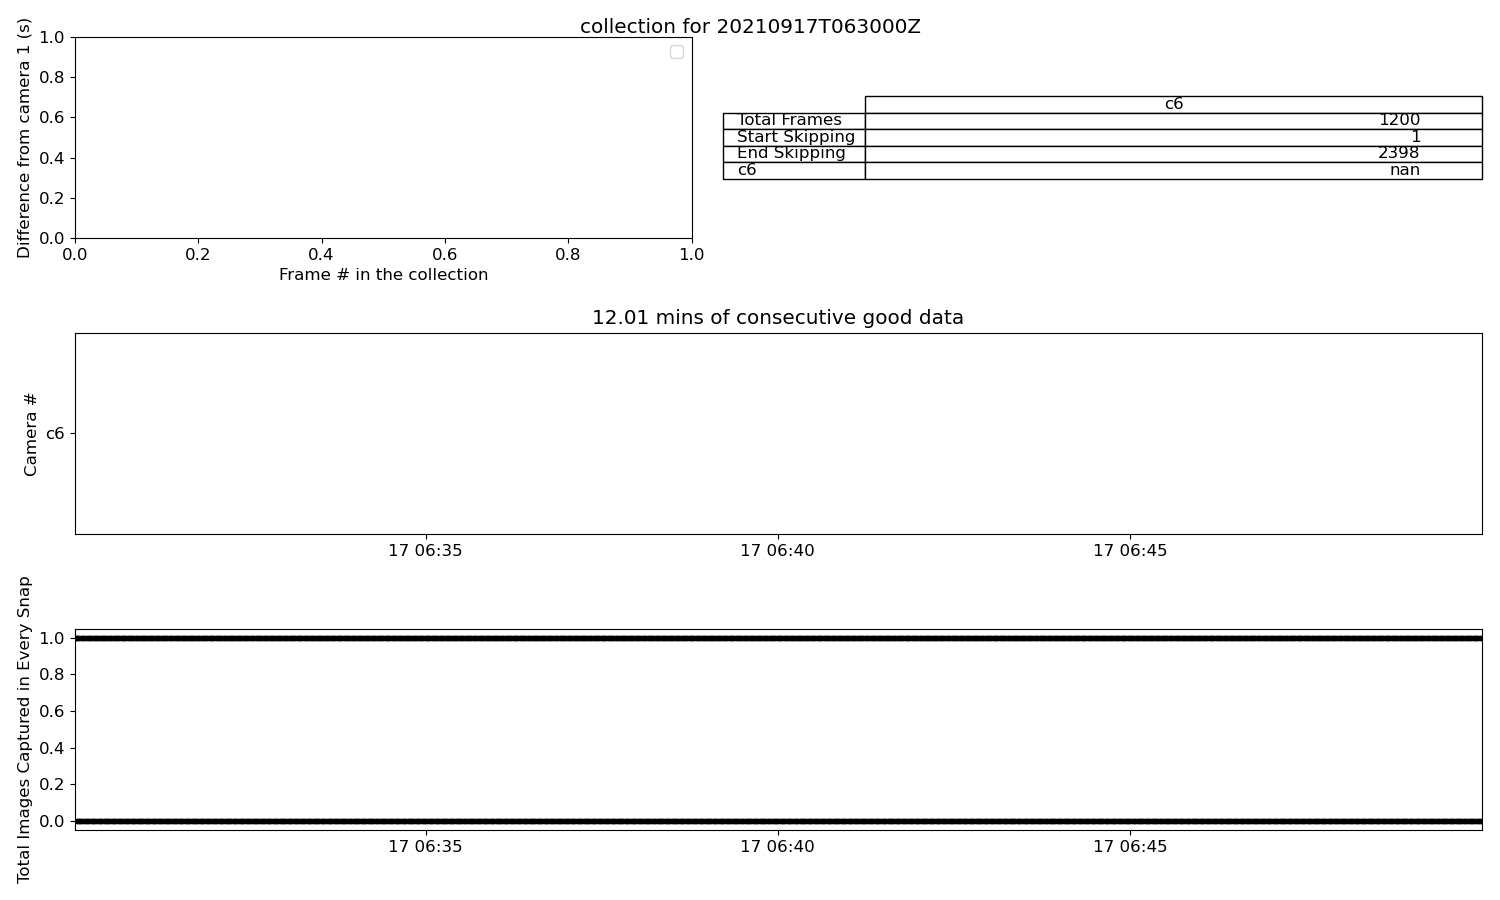

In [4]:
Image.open(os.path.join(DIR, PNG))

In [5]:
with open(os.path.join(DIR, PICKLE), 'rb') as f:
    x = pickle.load(f)
x['captureArray'] = x['captureArray'].squeeze()
x['captures'] = np.array(x['captures']).flatten()
x['missingFrames'] = x['missingFrames'][0]
x.keys()


dict_keys(['captureArray', 'time', 'startSkipping', 'endSkipping', 'cams_all', 'totalCaptured', 'captures', 'missingFrames', 'beginGoodTimes', 'endGoodTimes'])

In [6]:
x

{'captureArray': array([1., 0., 1., ..., 0., 0., 0.]),
 'time': array([datetime.datetime(2021, 9, 17, 6, 30, 0, 972178),
        datetime.datetime(2021, 9, 17, 6, 30, 1, 472178),
        datetime.datetime(2021, 9, 17, 6, 30, 1, 972178), ...,
        datetime.datetime(2021, 9, 17, 7, 1, 59, 472178),
        datetime.datetime(2021, 9, 17, 7, 1, 59, 972178),
        datetime.datetime(2021, 9, 17, 7, 2, 0, 472178)], dtype=object),
 'startSkipping': [1],
 'endSkipping': [2398],
 'cams_all': ['c6'],
 'totalCaptured': array([1., 0., 1., ..., 0., 0., 0.]),
 'captures': array([1.6318602e+09, 1.6318602e+09, 1.6318602e+09, ..., 1.6318614e+09,
        1.6318614e+09, 1.6318614e+09]),
 'missingFrames': array([   1,    3,    5, ..., 3837, 3838, 3839]),
 'beginGoodTimes': datetime.datetime(2021, 9, 17, 6, 49, 59, 472178),
 'endGoodTimes': datetime.datetime(2021, 9, 17, 6, 50, 0, 472178)}

# Data Availability

Text(0, 0.5, 'Hs')

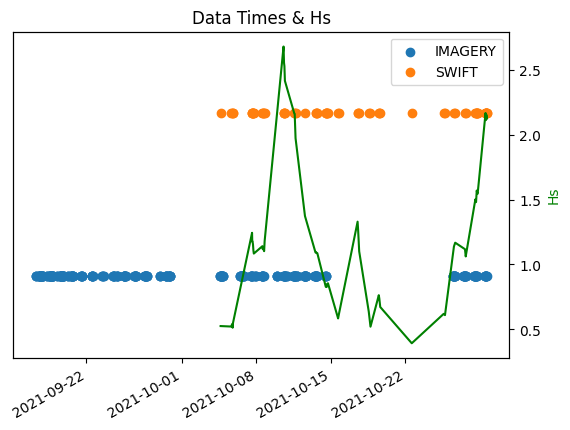

In [7]:
files = [path for path in glob(DIR+'/*.avi')]
datestr = [re.search(r'\d{8}T\d{6}Z',path)[0] for path in glob(DIR+'/*.pickle')]
times = [pd.Timestamp(re.search(r'\d{8}T\d{6}Z',path)[0]) for path in glob(DIR+'/*.pickle')]
fig = plt.figure()
plt.scatter(times, np.ones(len(times)), label='IMAGERY')
fig.autofmt_xdate()
plt.title('Data Times & Hs')
df = pd.read_csv('../data/mission_df.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
# df = df.set_index('time')
plt.scatter(pd.to_datetime(df['time']), np.ones(len(df))+0.1, label='SWIFT')
plt.legend()
plt.ylim([0.95, 1.15])
plt.yticks([])
plt.twinx().plot(df['time'], df['Hs [m] (8marray)'], c='g')
plt.ylabel('Hs', c='g')


In [9]:
! ffmpeg -i input.avi -c:v png -pix_fmt gray output.avi -y

ffmpeg version 7.0 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.3.9.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libopenvino -

In [11]:
cap = cv2.VideoCapture('input.avi')

different_pixels = 0

for i in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))-1):
    _, frame = cap.read()
    different_pixels += (
            np.sum(frame[:,:,0] != frame[:,:,1]) +
            np.sum(frame[:,:,0] != frame[:,:,2]) +
            np.sum(frame[:,:,1] != frame[:,:,2])
        )
print(f'There were {different_pixels} differences between channels')

There were 0 differences between channels


(1600, 500, 3)
(1600, 500, 3)


(-0.5, 499.5, -0.5, 1599.5)

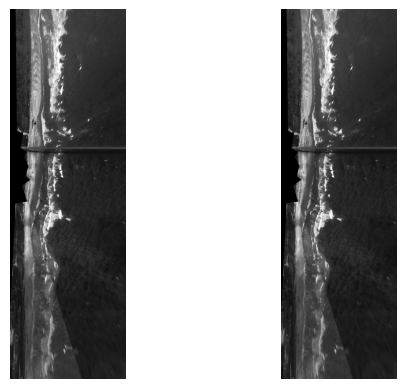

In [2]:
cap = cv2.VideoCapture('input.avi')
no_cap = cv2.VideoCapture('output.avi')

_, frame = cap.read()
_, no_frame = no_cap.read()

print(frame.shape)
print(no_frame.shape)
np.all(frame == no_frame)
fig, axs = plt.subplots(1, 2)
axs[0].imshow(frame)
axs[1].imshow(no_frame)
axs[0].axis('off')
axs[1].axis('off')


In [13]:
((cap.get(cv2.CAP_PROP_FRAME_COUNT) == no_cap.get(cv2.CAP_PROP_FRAME_COUNT))&
 (cap.get(cv2.CAP_PROP_FRAME_WIDTH) == no_cap.get(cv2.CAP_PROP_FRAME_WIDTH))&
 (cap.get(cv2.CAP_PROP_FRAME_HEIGHT) == no_cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))


cap = cv2.VideoCapture('input.avi')
no_cap = cv2.VideoCapture('output.avi')

different_pixels = 0

for i in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))-1):
    _, frame = cap.read()
    _, no_frame = no_cap.read()
    different_pixels += (
            np.sum(frame[:,:,0] != no_frame[:,:,0]) +
            np.sum(frame[:,:,1] != no_frame[:,:,1]) +
            np.sum(frame[:,:,2] != no_frame[:,:,2])
        )
print(f'There were {different_pixels} differences between files')

There were 0 differences between files


In [14]:
! ls -alh *.avi

-rwx------@ 1 mleclair  staff   2.9G Jun  5 11:33 input.avi
-rw-r--r--@ 1 mleclair  staff   1.3G Jun  7 10:22 output.avi
-rw-r--r--@ 1 mleclair  staff   1.3G Jun  5 13:52 output1.avi


In [11]:
1 - (1.3/2.9)

0.5517241379310345

This is a 55% lossless reduction by going from rawvideo Y800 to mpng gray (y8). They are also pixelwise identical

In [16]:
# Images

(-0.5, 1599.5, -0.5, 499.5)

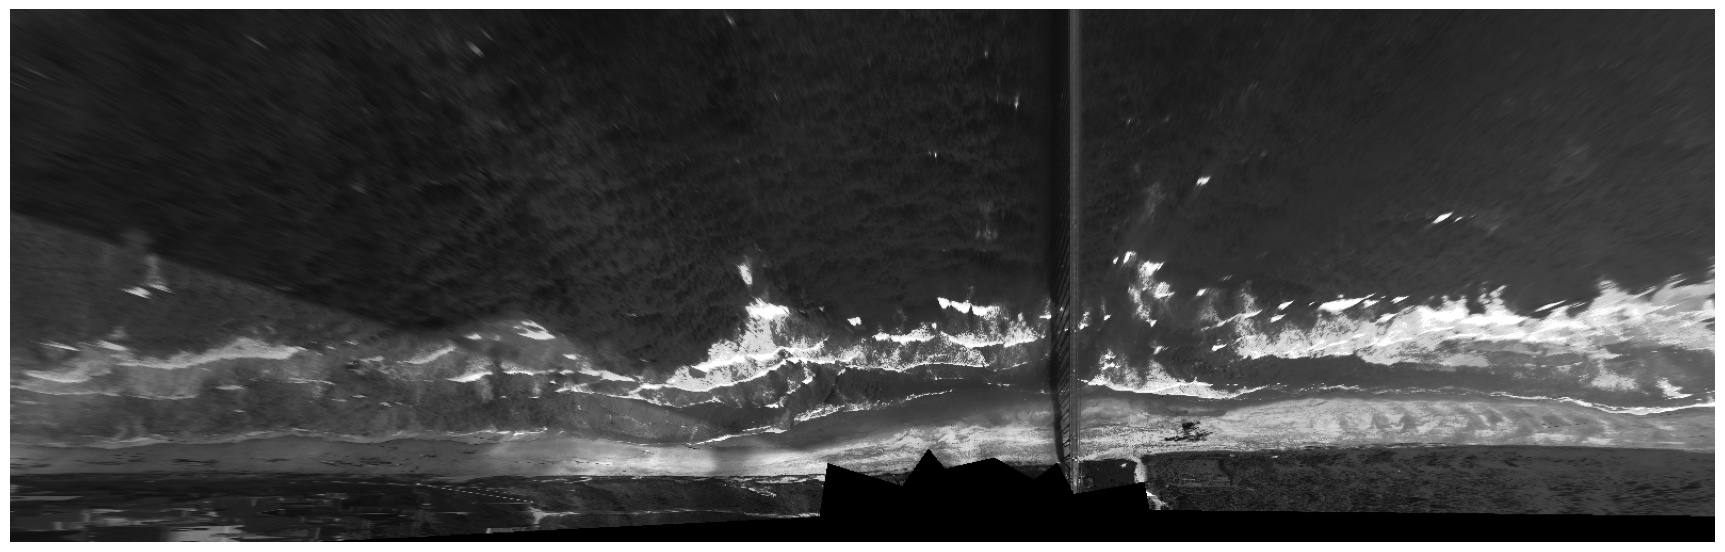

In [22]:
cap = cv2.VideoCapture('input.avi')
_, frame = cap.read()
frame = frame[..., 0] # Not sure why it always comes out as (..., 3) 
plt.figure(figsize=(22, 10))
plt.imshow(frame.T)
plt.axis('off')

Text(0, 0.5, 'Density [ignoring zeros]')

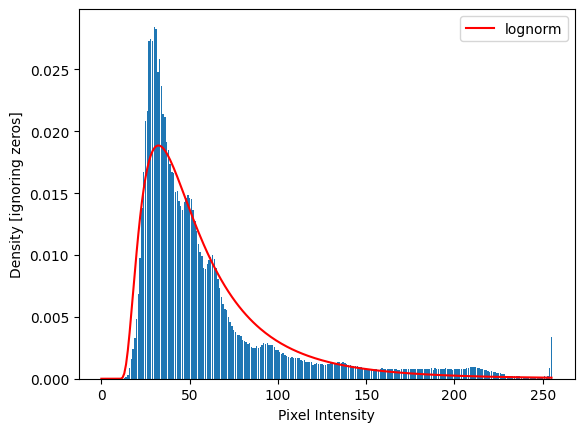

In [28]:
hist = np.zeros(256)
for i in range(1, 256):
    hist[i] = np.sum(frame==i)
hist /= np.sum(hist)
plt.bar(np.arange(256)[1:], hist[1:])
shape, loc, scale = lognorm.fit(frame[frame>0])
x = np.arange(256)
pdf = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf, c='r', label='lognorm')
plt.legend()
plt.xlabel('Pixel Intensity')
plt.ylabel('Density [ignoring zeros]')

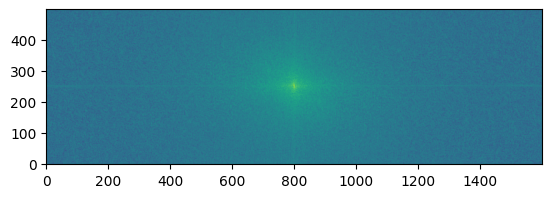

In [348]:
from scipy import fft

FS = fft.fftn(frame)
plt.imshow(np.log(np.abs(fft.fftshift(FS))**2), cmap='viridis')


## Timex

(-0.5, 1599.5, -0.5, 499.5)

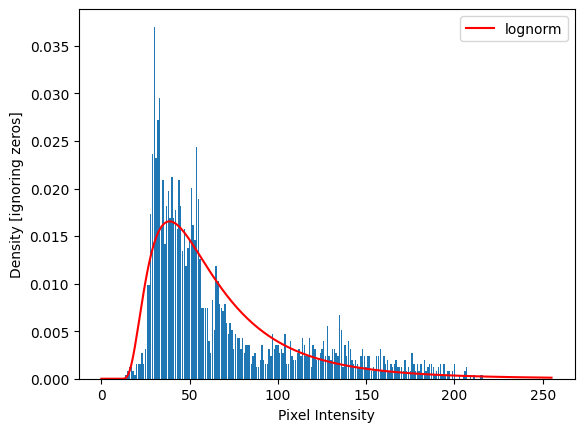

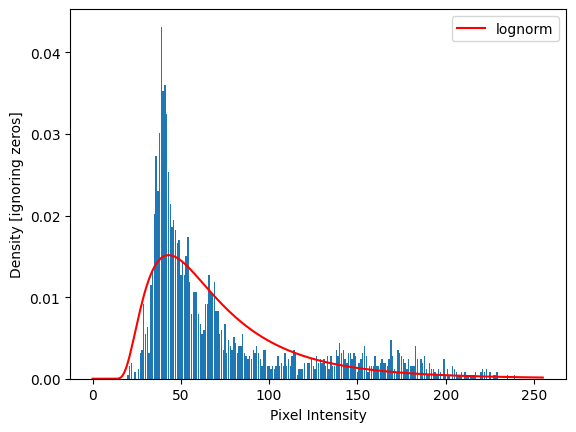

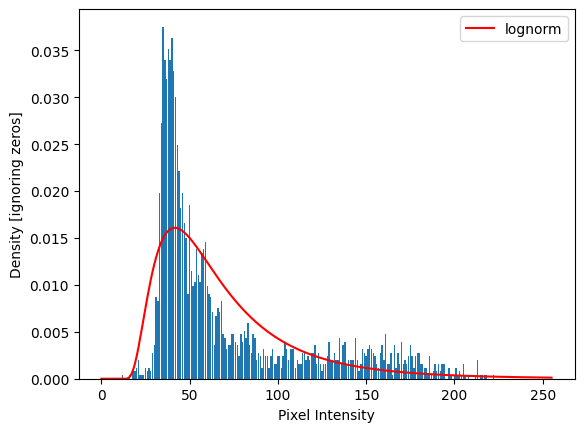

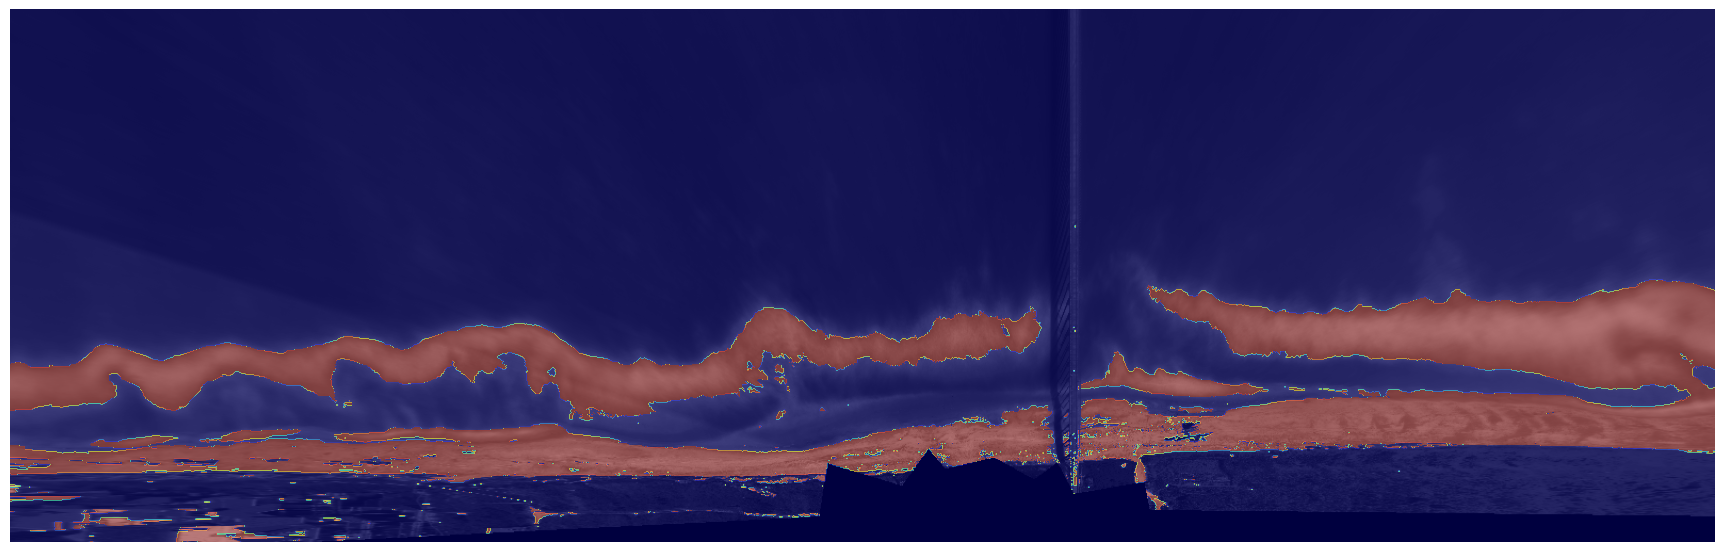

In [34]:
cap = cv2.VideoCapture('input.avi')
_, frame = cap.read()
frame = frame[..., 0]

timex = frame.astype(int)
min = frame
max = frame

N = int((10 * 60 / 2) - 1)
for i in range(N):
    _, frame = cap.read()
    frame = frame[..., 0]
    timex += frame
    min = np.minimum(min, frame)
    max = np.maximum(max, frame)
timex = timex / N

hist = np.zeros(256)
for i in range(1, 256):
    hist[i] = np.sum(timex==i)
hist /= np.sum(hist)
plt.figure()
plt.bar(np.arange(256)[1:], hist[1:])
shape, loc, scale = lognorm.fit(timex[timex>0])
x = np.arange(256)
pdf = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf, c='r', label='lognorm')
plt.legend()
plt.xlabel('Pixel Intensity')
plt.ylabel('Density [ignoring zeros]')

timex = frame.astype(int)

N = int((10 * 60 / 2) - 1)
for i in range(N):
    _, frame = cap.read()
    frame = frame[..., 0]
    timex += frame
    min = np.minimum(min, frame)
    max = np.maximum(max, frame)
timex = timex / N

hist = np.zeros(256)
for i in range(1, 256):
    hist[i] = np.sum(timex==i)
hist /= np.sum(hist)
plt.figure()
plt.bar(np.arange(256)[1:], hist[1:])
shape, loc, scale = lognorm.fit(timex[timex>0])
x = np.arange(256)
pdf = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf, c='r', label='lognorm')
plt.legend()
plt.xlabel('Pixel Intensity')
plt.ylabel('Density [ignoring zeros]')

timex = frame.astype(int)

N = int((10 * 60 / 2) - 1)
for i in range(N):
    _, frame = cap.read()
    frame = frame[..., 0]
    timex += frame
    min = np.minimum(min, frame)
    max = np.maximum(max, frame)
timex = timex / N

hist = np.zeros(256)
for i in range(1, 256):
    hist[i] = np.sum(timex==i)
hist /= np.sum(hist)
plt.figure()
plt.bar(np.arange(256)[1:], hist[1:])
shape, loc, scale = lognorm.fit(timex[timex>0])
x = np.arange(256)
pdf = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf, c='r', label='lognorm')
plt.legend()
plt.xlabel('Pixel Intensity')
plt.ylabel('Density [ignoring zeros]')


timex = np.swapaxes(timex, 0, 1)  # Not sure why it always comes out as (..., 3) Also swapping XY for vis
min = np.swapaxes(min, 0, 1)  # Not sure why it always comes out as (..., 3) Also swapping XY for vis
max = np.swapaxes(max, 0, 1)  # Not sure why it always comes out as (..., 3) Also swapping XY for vis
plt.figure(figsize=(22, 10))
plt.imshow(timex)
plt.imshow(timex>120, cmap='jet', alpha=0.5)
plt.axis('off')

Text(0.5, 0, 'Cross Shore Distance')

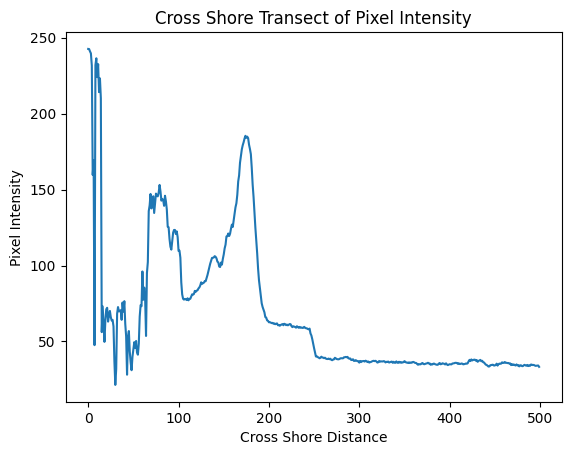

In [35]:
plt.plot(timex[:, 199])
plt.title('Cross Shore Transect of Pixel Intensity')
plt.ylabel('Pixel Intensity')
plt.xlabel('Cross Shore Distance')

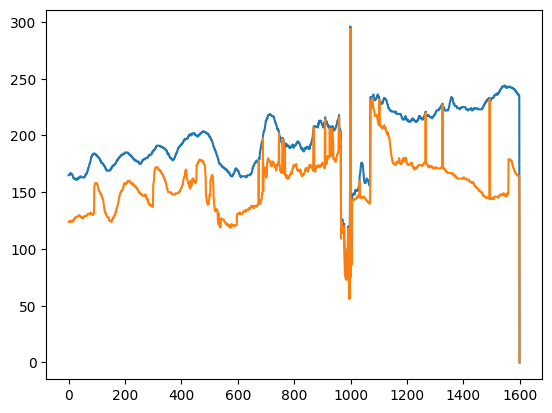

In [36]:
threshold = 125
limits = np.zeros((1600, 2))

for i in range(1600-1):
    start = None
    end = None
    for j in range(500):
        if start is None and timex[499-j, i] >= threshold:
            start = 499 - j
        
        if start is not None and end is None and timex[499-j, i] < threshold:
            end  = 499 - j 
            
    if start is not None and end is not None:
        limits[i] = [start, end]
    else:
        limits[i] = limits[i-1]
        

plt.plot(limits[:, 0])
plt.plot(limits[:, 1])

# plt.plot(timex[:, 100])
# plt.axhline(100)
# plt.axvline(start, c='r')
# plt.axvline(end, c='r')""

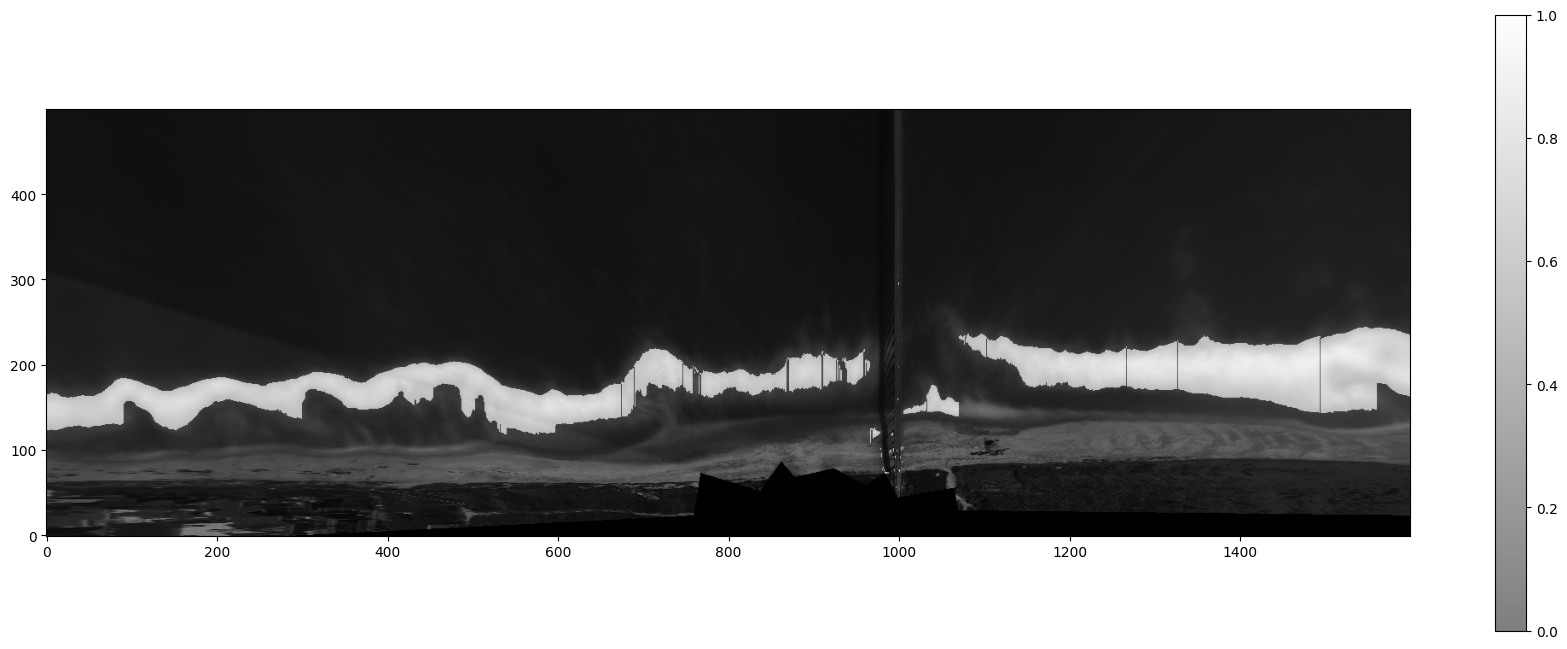

In [37]:
xs, ys = np.meshgrid(np.arange(500), np.arange(1600))
plt.figure(figsize=(22, 8))
mask = (xs <= limits[:, 0, np.newaxis]) & (xs >= limits[:, 1, np.newaxis])
plt.imshow(timex)
plt.imshow(mask.T, cmap='gray', alpha=0.5)
plt.colorbar()


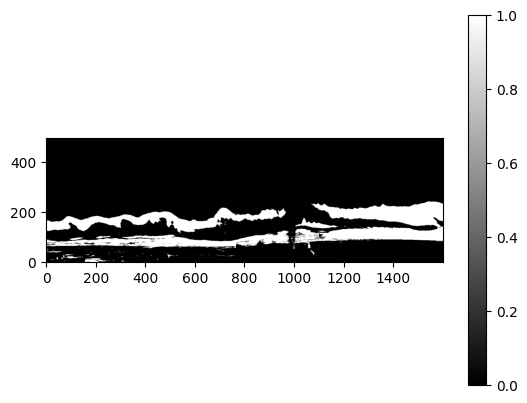

In [737]:
plt.imshow((timex > 125).astype(np.float64))
plt.colorbar()

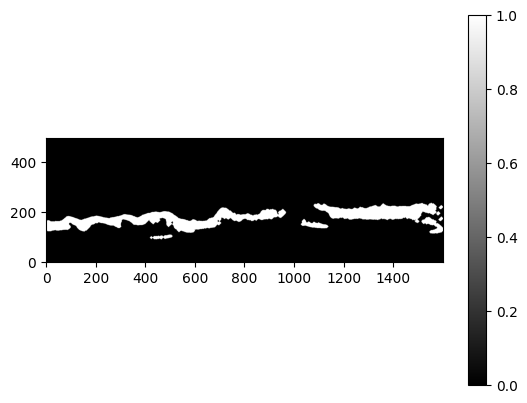

In [48]:
from skimage.segmentation import flood, flood_fill
import scipy.ndimage as nd
threshold = 120
thresholded = (timex>threshold).astype(np.float64)
mask = np.zeros_like(timex).astype(bool)
zeros = np.zeros(1600)
for i in range(0, 1600-1, 5):
    # thresh = timex[:, i] - threshold
    zero_crossings = np.where(thresholded[:, i])[0]
    if not zero_crossings.size==0:
        zeros[i] = zero_crossings[-1]
        mask = mask | flood(thresholded, (zero_crossings[-1], i), tolerance=0.5)
# mask = mask.astype(np.uint8)
# mmask = np.zeros_like(timex).astype(bool)
# for i in range(1600-1):
#     print(i)
#     thresh = mask - 1
#     zero_crossings = np.where(np.diff(np.signbit(thresh)))[0]
#     if not zero_crossings.size==0:
#            mmask = mmask | flood(mask, (zero_crossings[-1], i), tolerance=1)
plt.imshow(
    nd.binary_dilation(
            nd.binary_erosion(
                (max>245) & mask,
            iterations=6),
        iterations=6),
)

plt.colorbar()

(-0.5, 1599.5, -0.5, 499.5)

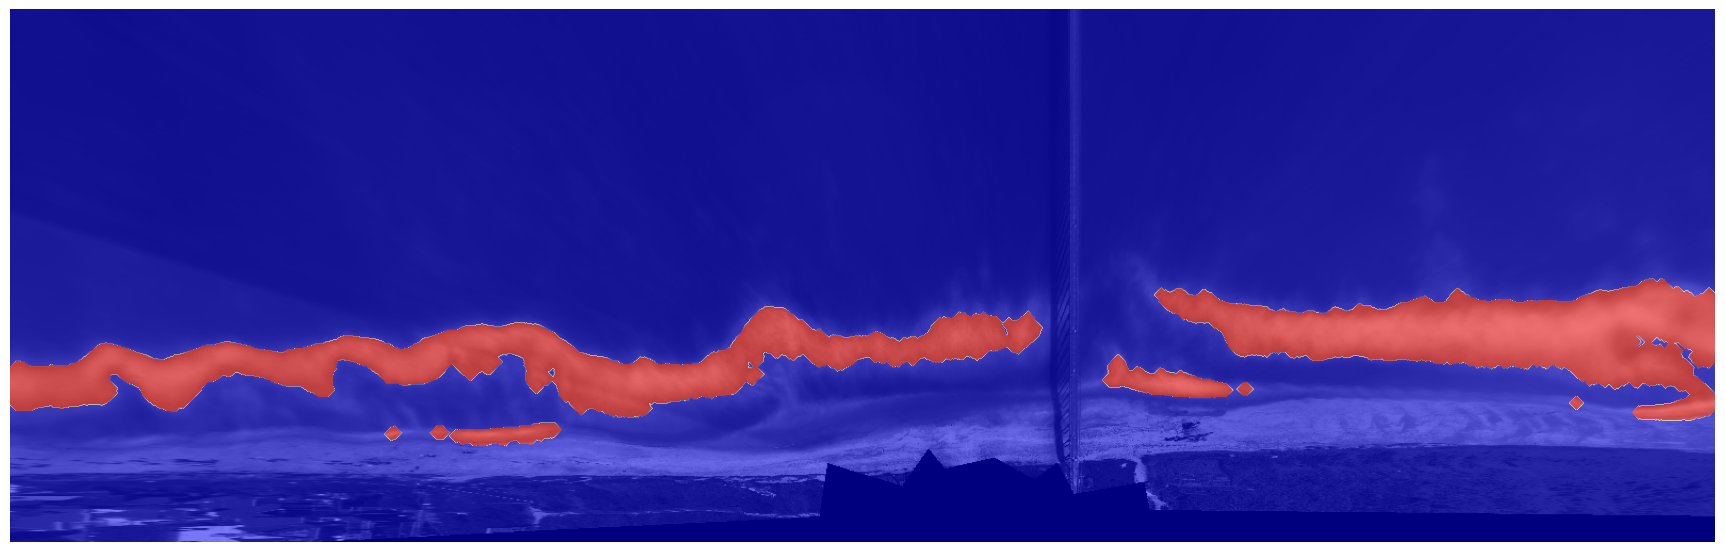

In [49]:
plt.figure(figsize=(22, 10))
plt.imshow(timex)
it = 5
plt.imshow(
   nd.binary_dilation(
       nd.binary_erosion(
           (max>230) & mask,
           iterations=it),
    iterations=it+1),
alpha=0.5, cmap='bwr')

# plt.imshow((max>250) & mask, cmap='jet', alpha=0.5)
plt.axis('off')

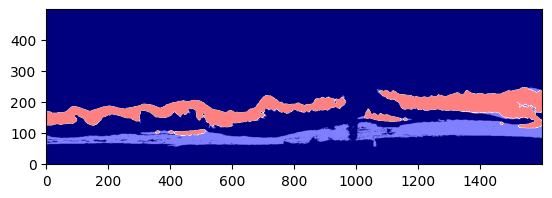

In [50]:
plt.imshow(mask)
plt.imshow(
   nd.binary_dilation(
       nd.binary_erosion(
           (max>230) & mask,
           iterations=it),
    iterations=it),
alpha=0.5, cmap='bwr')


## Variance Time Series

100%|██████████| 3840/3840 [00:06<00:00, 591.29it/s]


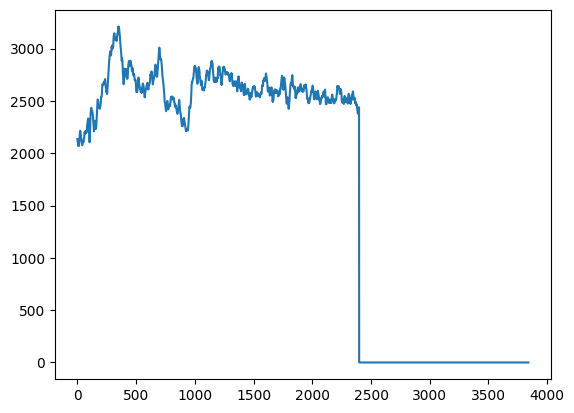

In [742]:
cap = cv2.VideoCapture('input.avi')

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
variance = np.zeros(N)

for i in tqdm(range(N)):
    _, frame = cap.read()
    frame = frame[..., 0]
    variance[i] = frame.var()

plt.plot(variance)

In [743]:
x

{'captureArray': array([1., 0., 1., ..., 0., 0., 0.]),
 'time': array([datetime.datetime(2021, 9, 17, 6, 30, 0, 972178),
        datetime.datetime(2021, 9, 17, 6, 30, 1, 472178),
        datetime.datetime(2021, 9, 17, 6, 30, 1, 972178), ...,
        datetime.datetime(2021, 9, 17, 7, 1, 59, 472178),
        datetime.datetime(2021, 9, 17, 7, 1, 59, 972178),
        datetime.datetime(2021, 9, 17, 7, 2, 0, 472178)], dtype=object),
 'startSkipping': [1],
 'endSkipping': [2398],
 'cams_all': ['c6'],
 'totalCaptured': array([1., 0., 1., ..., 0., 0., 0.]),
 'captures': array([1.6318602e+09, 1.6318602e+09, 1.6318602e+09, ..., 1.6318614e+09,
        1.6318614e+09, 1.6318614e+09]),
 'missingFrames': (array([   1,    3,    5, ..., 3837, 3838, 3839]),),
 'beginGoodTimes': datetime.datetime(2021, 9, 17, 6, 49, 59, 472178),
 'endGoodTimes': datetime.datetime(2021, 9, 17, 6, 50, 0, 472178)}

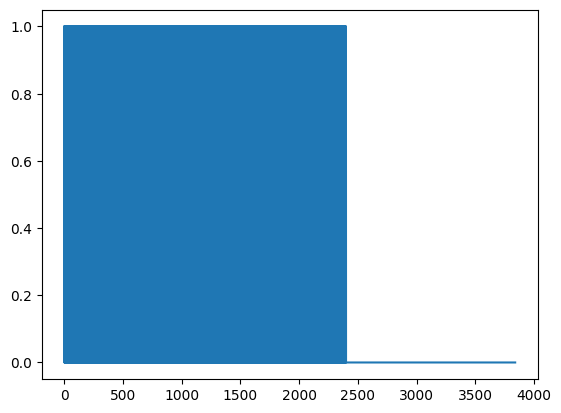

In [755]:
plt.plot(x['totalCaptured'])

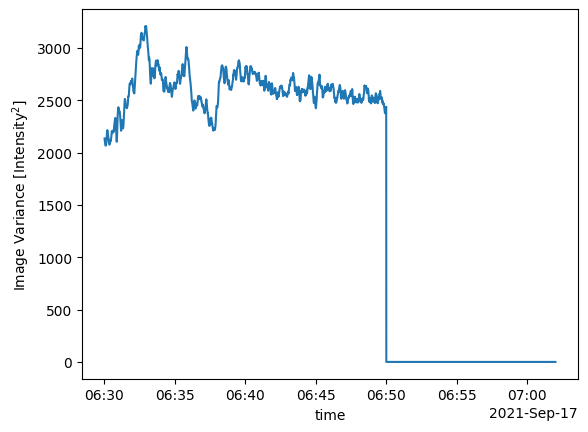

In [806]:
ds = xr.Dataset(
    data_vars=dict(
        variance=  xr.DataArray(
                data   = variance,
                dims   = ['time'],
                # coords = {'time': times},
                attrs  = {
                    'long_name': 'Image Variance',
                    'units'     : 'Intensity$^2$'
                    }
                ),
    ),
    coords=dict(
        time=time,
    ),
)
ds.variance.plot()

In [775]:
for k, v in x.items():
    try:
        if(len(v)==1):
            print(k, '-', v)
        print(k, len(v))
    except:
        print(k, '-', v)
        

captureArray 3840
time 3840
startSkipping - [1]
startSkipping 1
endSkipping - [2398]
endSkipping 1
cams_all - ['c6']
cams_all 1
totalCaptured 3840
captures 1200
missingFrames - (array([   1,    3,    5, ..., 3837, 3838, 3839]),)
missingFrames 1
beginGoodTimes - 2021-09-17 06:49:59.472178
endGoodTimes - 2021-09-17 06:50:00.472178


In [65]:
x['totalCaptured']

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

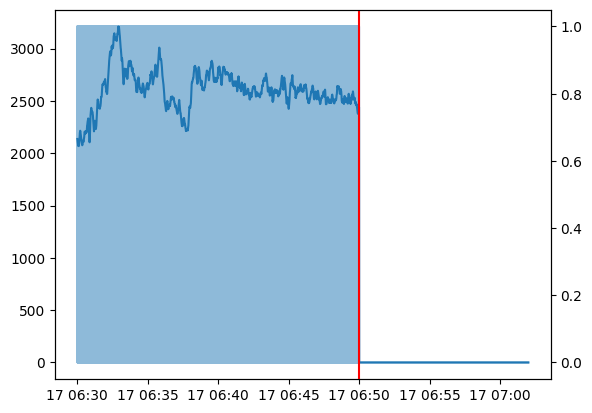

In [792]:
plt.plot(x['time'], x['missingFrames'][0])
plt.plot(x['time'], variance)
plt.twinx().plot(x['time'], x['totalCaptured'], alpha=0.5)
plt.axvline(x['endGoodTimes'], c='r')

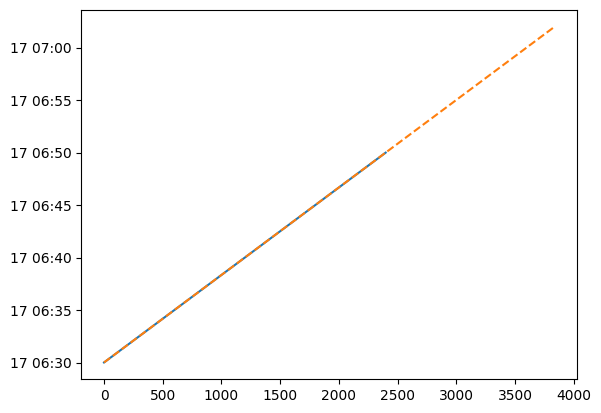

In [787]:
plt.plot(2 * np.arange(1200), 
pd.to_datetime(x['captures'] * 1e9))
plt.plot(range(N), x['time'], linestyle='--')

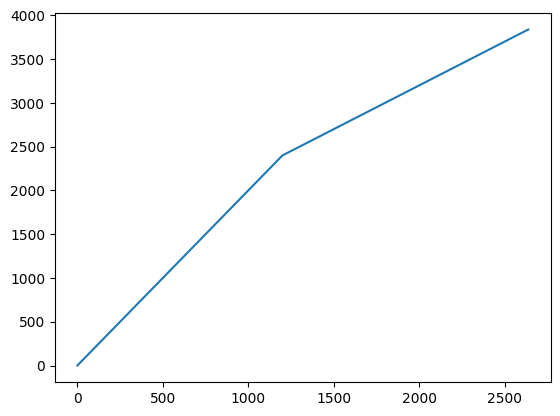

In [790]:
plt.plot(x['missingFrames'][0])

In [814]:
# Processing Variance for Everything

TypeError: strftime() takes exactly 2 positional arguments (1 given)

In [819]:
# Data inventory
for date in datestr:
    if not (
        os.path.isfile(f'/Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery/ArgusFF_{date}_RectifiedVideo.avi') and 
        os.path.isfile(f'/Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery/ArgusFF_{date}_headerData.pickle')):
        print(date)


In [837]:

date = datestr[101]
vid = f'/Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery/ArgusFF_{date}_RectifiedVideo.avi'
pkl = f'/Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery/ArgusFF_{date}_headerData.pickle'


cap = cv2.VideoCapture(vid)

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
variance = np.zeros(N)

for i in tqdm(range(N)):
    _, frame = cap.read()
    frame = frame[..., 0]
    variance[i] = frame.var()

plt.plot(variance)

  0%|          | 13/3840 [00:02<13:55,  4.58it/s]


KeyboardInterrupt: 

In [838]:
datestr = [re.search(r'\d{8}T\d{6}Z',path)[0] for path in glob(DIR+'/*.pickle')]
ds = None
for date in tqdm(datestr):
    vid = f'/Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery/ArgusFF_{date}_RectifiedVideo.avi'
    pkl = f'/Volumes/Data/DuckFRF/DUNEXMainExp_2021/FRF_imagery/DunexImagery/ArgusFF_{date}_headerData.pickle'

    cap = cv2.VideoCapture(vid)

    N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    variance = np.zeros(N)

    for i in range(N):
        _, frame = cap.read()
        frame = frame[..., 0]
        variance[i] = frame.var()

    with open(pkl, 'rb') as f:
        data = pickle.load(f)
    time = data['time']

    temp_ds = xr.Dataset(
            data_vars=dict(
                variance=  xr.DataArray(
                        data   = np.zeros_like(time),
                        dims   = ['time'],
                        # coords = {'time': times},
                        attrs  = {
                            'long_name': 'Image Variance',
                            'units'     : 'Intensity$^2$'
                            }
                        ),
            ),
            coords=dict(
                time=time,
            ),
        )
    if ds is None:
        ds = temp_ds
    else:
        ds = xr.concatenate(ds, temp_ds)

In [839]:
dss = xr.Dataset(
    data_vars=dict(
        variance=  xr.DataArray(
                data   = np.zeros_like(time),
                dims   = ['time'],
                # coords = {'time': times},
                attrs  = {
                    'long_name': 'Image Variance',
                    'units'     : 'Intensity$^2$'
                    }
                ),
    ),
    coords=dict(
        time=time,
    ),
)

In [841]:
ds

<xarray.Dataset> Size: 61kB
Dimensions:   (time: 3840)
Coordinates:
  * time      (time) datetime64[ns] 31kB 2021-09-23T13:01:00.460613 ... 2021-...
Data variables:
    variance  (time) object 31kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0

In [840]:
dss

<xarray.Dataset> Size: 61kB
Dimensions:   (time: 3840)
Coordinates:
  * time      (time) datetime64[ns] 31kB 2021-09-23T14:31:00.269420 ... 2021-...
Data variables:
    variance  (time) object 31kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0

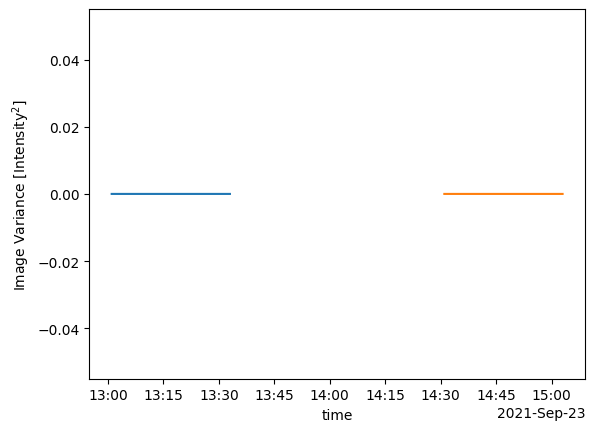

In [844]:
ds.variance.astype(int).plot()
dss.variance.astype(int).plot()

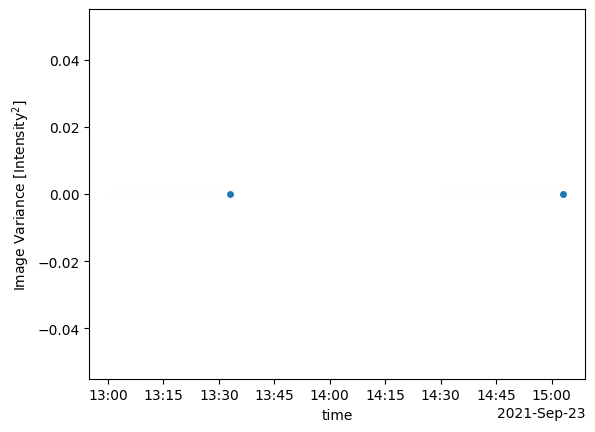

In [859]:
dsss = xr.concat([ds, dss], 'time')
dsss.variance.astype(int).plot.scatter()


In [864]:
dsss

<xarray.Dataset> Size: 123kB
Dimensions:   (time: 7680)
Coordinates:
  * time      (time) datetime64[ns] 61kB 2021-09-23T13:01:00.460613 ... 2021-...
Data variables:
    variance  (time) object 61kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0

In [866]:
len(dsss.variance)

7680

In [867]:
len(dsss.time)

7680

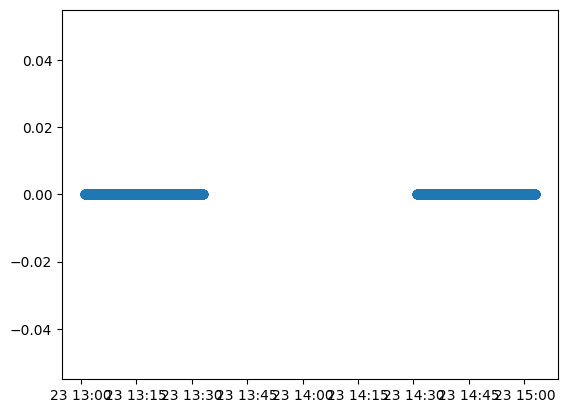

In [869]:
plt.scatter(dsss.time, dsss.variance)